# Dataset & LIbraries

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from keras import Sequential, layers

from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix


from PIL import Image

2026-04-20 20:37:04.397144: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776717424.648425      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776717424.716330      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776717425.287196      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776717425.287272      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776717425.287276      55 computation_placer.cc:177] computation placer alr

In [2]:
source_dir = "/kaggle/input/datasets/geadalfa/cracked-non-cracked-surface-datasets/Bangunan Retak"
dest_dir = "/kaggle/working/NewDataset"

Splitting into separate Train, Val & Test folders

In [ ]:
import splitfolders
splitfolders.ratio(source_dir, output=dest_dir, ratio=(.8, .15, .05), group_prefix=None, move=False)

# Preprocessing

Image Dataset Preprocessing and Loading

In [ ]:
batch_size = 32
image_size = (224, 224)

train = keras.preprocessing.image_dataset_from_directory(dest_dir + "/train", label_mode = "categorical", batch_size = batch_size, image_size = image_size, )
val = keras.preprocessing.image_dataset_from_directory(dest_dir + "/val", label_mode = "categorical", batch_size = batch_size, image_size = image_size, shuffle = False, )
test = keras.preprocessing.image_dataset_from_directory(dest_dir + "/test", label_mode = "categorical", batch_size = batch_size, image_size = image_size, shuffle = False, )

train = train.prefetch(buffer_size=tf.data.AUTOTUNE)
val = val.prefetch(buffer_size=tf.data.AUTOTUNE)
test = test.prefetch(buffer_size=tf.data.AUTOTUNE)


Class Weight Computation for Imbalanced Datasets

In [ ]:
train_dir = dest_dir + "/train"

class_names = sorted(os.listdir(train_dir))

y_train_simulated = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    num_images = len(os.listdir(class_path))
    y_train_simulated.extend([i] * num_images)

y_train_simulated = np.array(y_train_simulated)

class_labels = np.unique(y_train_simulated)
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=y_train_simulated
)

class_weights = dict(zip(class_labels, class_weights_array))

class_indices = {class_names[i]: i for i in range(len(class_names))}
print(f"Class indices: {class_indices}")
print(f"Calculated weights: {class_weights}")


# Hyperparameter optimization

In [ ]:
!pip install optuna
!pip install optuna-integration[tfkeras]

Defining Optuna Objective Function for ANN Hyperparameter Search

In [ ]:
import optuna
from optuna.integration import TFKerasPruningCallback

def objective(trial):
    # 1. Clear session to avoid cluttering memory
    tf.keras.backend.clear_session()
    
    ## --- 1. Suggest Hyperparameters ---
    n_layers = trial.suggest_int("n_layers", 1, 2)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    
    # --- 2. Build Model Dynamically ---
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(224, 224, 3)))
    model.add(tf.keras.layers.Rescaling(1./255))
    model.add(tf.keras.layers.Flatten())
    
    for i in range(n_layers):
        num_units = trial.suggest_int(f"n_units_l{i}", 512, 1024, step=64)
        model.add(tf.keras.layers.Dense(num_units, activation="relu"))
        model.add(tf.keras.layers.Dropout(dropout_rate))
    
    model.add(tf.keras.layers.Dense(2, activation="softmax"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # 4. Train with Pruning Callback
    # This stops unpromising trials early to save time
    callbacks = [
        TFKerasPruningCallback(trial, monitor="val_accuracy")
    ]
    
    history = model.fit(
        train, # Your existing generator
        validation_data=val,
        epochs=15,       # Set a reasonable max
        callbacks=callbacks,
        class_weight=class_weights,
        steps_per_epoch=100,
        validation_steps=20
    )
    
    # 5. Return the metric to optimize
    return history.history["val_accuracy"][-1]

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Best trial: {study.best_trial.value}")
print(f"Best params: {study.best_trial.params}")

# Training

Reconstructing and Training the Final Model with Optimal Hyperparameters

In [10]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.15696416282364267),


    layers.Dense(2, activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    77,070,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,071,874 (294.01 MB)

 Trainable params: 77,071,874 (294.01 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2.0e-05),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['Accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')]
)


In [12]:
callbacks = [keras.callbacks.EarlyStopping(patience = 7, restore_best_weights=True)]
history = model.fit(
        train,
        validation_data=val,
        epochs=30,
        callbacks=callbacks,
        class_weight=class_weights,
    )

Epoch 1/30
2403/2403 ━━━━━━━━━━━━━━━━━━━━ 127s 52ms/step - Accuracy: 0.6444 - loss: 0.7179 - precision: 0.6444 - recall: 0.6444 - val_Accuracy: 0.8380 - val_loss: 0.4954 - val_precision: 0.8380 - val_recall: 0.8380
Epoch 2/30
2403/2403 ━━━━━━━━━━━━━━━━━━━━ 111s 46ms/step - Accuracy: 0.7878 - loss: 0.5430 - precision: 0.7878 - recall: 0.7878 - val_Accuracy: 0.8086 - val_loss: 0.5472 - val_precision: 0.8086 - val_recall: 0.8086
Epoch 3/30
2403/2403 ━━━━━━━━━━━━━━━━━━━━ 112s 47ms/step - Accuracy: 0.8090 - loss: 0.5207 - precision: 0.8090 - recall: 0.8090 - val_Accuracy: 0.8471 - val_loss: 0.4541 - val_precision: 0.8471 - val_recall: 0.8471
Epoch 4/30
2403/2403 ━━━━━━━━━━━━━━━━━━━━ 115s 48ms/step - Accuracy: 0.8275 - loss: 0.5059 - precision: 0.8275 - recall: 0.8275 - val_Accuracy: 0.8496 - val_loss: 0.4856 - val_precision: 0.8496 - val_recall: 0.8496
Epoch 5/30
2403/2403 ━━━━━━━━━━━━━━━━━━━━ 124s 52ms/step - Accuracy: 0.8244 - loss: 0.5038 - precision: 0.8244 - recall: 0.8244 - val_Accura

# Evaluation & Visualization

Model Performance Evaluation on Test Dataset

In [13]:
#loss, accuracy, precision, recall = model.evaluate(test)
print(model.evaluate(test))

151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - Accuracy: 0.7356 - loss: 0.5004 - precision: 0.7356 - recall: 0.7356
[0.4529261589050293, 0.8466500043869019, 0.8466500043869019, 0.8466500043869019]


Visualizing Training History: Loss and Accuracy Curves

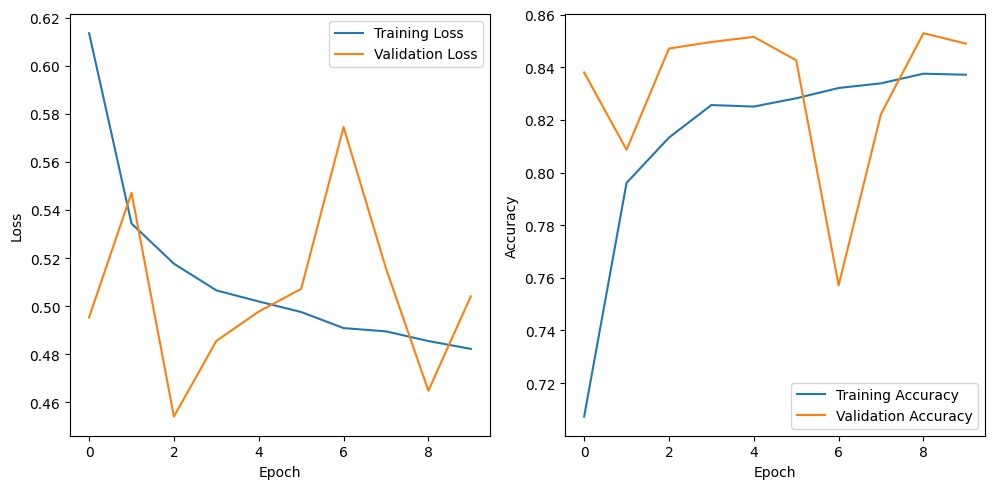

In [14]:
plt.figure(figsize=(15, 5))

# --- Loss ---
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# --- Accuracy ---
plt.subplot(1, 3, 2)
plt.plot(history.history['Accuracy'], label='Training Accuracy')
plt.plot(history.history['val_Accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Confusion Matrix Visualization and Error Analysis

In [ ]:
# Get true labels from file counts
test_dir = dest_dir + "/test"
class_names = sorted(os.listdir(test_dir))
y_true = []
for i, name in enumerate(class_names):
    class_path = os.path.join(test_dir, name)
    n = len(os.listdir(class_path))
    y_true.extend([i] * n)
y_true = np.array(y_true)

# Use the model to predict the classes
y_pred = np.argmax(model.predict(test), axis=1)


In [ ]:


# Compute and print confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualize confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print(conf_matrix)

Custom Probability Thresholding for Imbalance and Classification Performance Evaluation

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get raw probabilities (Shape: N, 2)
# Tip: Reset the generator before predicting to ensure order matches y_true
y_pred_probs = model.predict(test)

# 2. Isolate the probabilities for just the 'Cracked' class (Class 0)
cracked_probs = y_pred_probs[:, 0] 

# 3. Apply your custom threshold
threshold = 0.35

# If the probability of being cracked is greater than 0.35, label it 0 (Cracked)
# Otherwise, label it 1 (Non Cracked)
# np.where(condition, value_if_true, value_if_false)
y_pred_labels = np.where(cracked_probs > threshold, 0, 1)

# 4. Generate the new confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
class_names = list(class_names)

print(f"Applying Custom Threshold: {threshold}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_labels, target_names=class_names))

In [ ]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [19]:
model.save_weights("FFNN.weights.h5")